In [1]:
import data_helper
df_raw = data_helper.load('h',0,1,1,0)

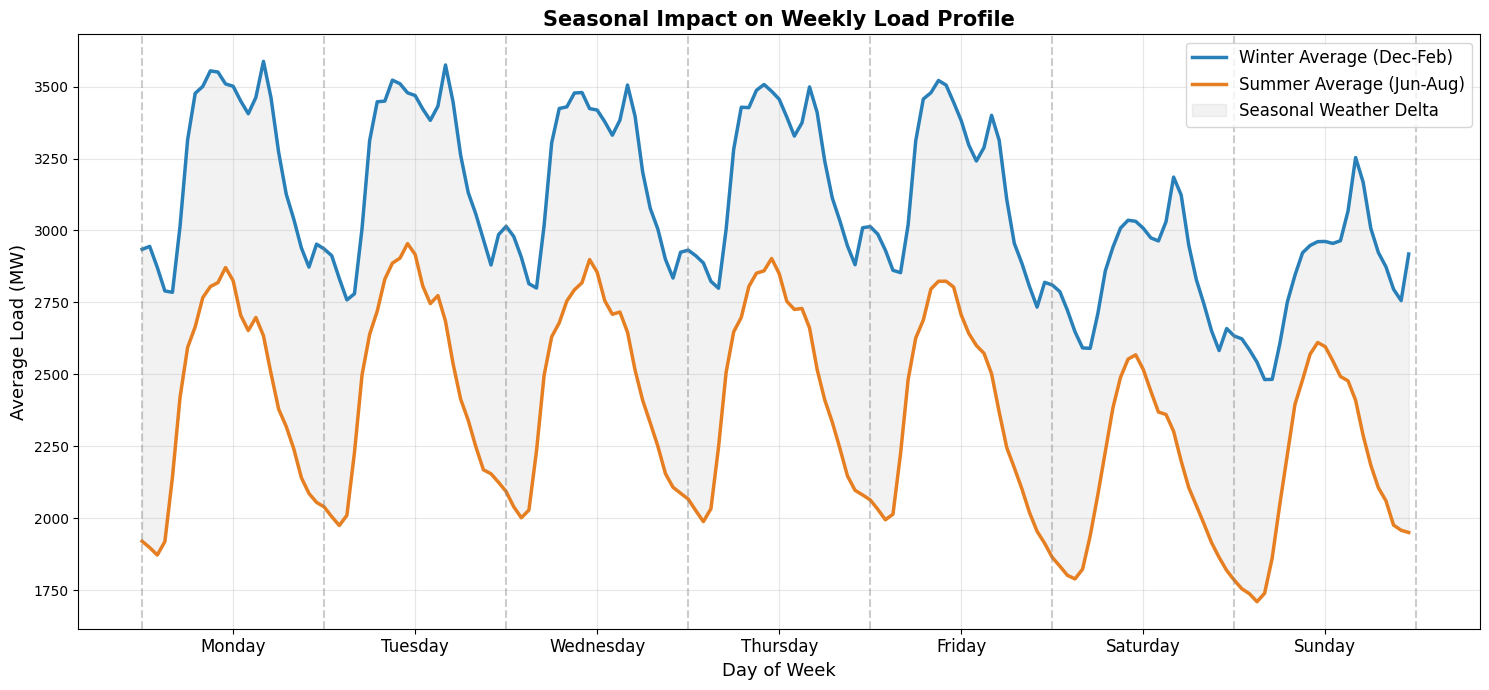

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TEMPORAL FEATURES
#df_raw = df_raw.reset_index()
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['day_of_week'] = df_raw['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
df_raw['month'] = df_raw['timestamp'].dt.month

#ISOLATE SEASONS
# Meteorological Winter (Dec, Jan, Feb) and Summer (Jun, Jul, Aug)
winter_mask = df_raw['month'].isin([12, 1, 2])
summer_mask = df_raw['month'].isin([6, 7, 8])

df_winter = df_raw[winter_mask]
df_summer = df_raw[summer_mask]

#  WEEKLY AVERAGES / SEASON
winter_avg = df_winter.groupby(['day_of_week', 'hour'])['load'].mean().reset_index()
summer_avg = df_summer.groupby(['day_of_week', 'hour'])['load'].mean().reset_index()


winter_avg['hour_of_week'] = winter_avg['day_of_week'] * 24 + winter_avg['hour']
summer_avg['hour_of_week'] = summer_avg['day_of_week'] * 24 + summer_avg['hour']

# ==========================================
# CHART: WINTER VS SUMMER WEEKLY LOAD CURVE
# ==========================================
plt.figure(figsize=(15, 7))


plt.plot(winter_avg['hour_of_week'], winter_avg['load'], 
         label='Winter Average (Dec-Feb)', color='#2980b9', linewidth=2.5)
plt.plot(summer_avg['hour_of_week'], summer_avg['load'], 
         label='Summer Average (Jun-Aug)', color='#e67e22', linewidth=2.5)

# Formatting
plt.title('Seasonal Impact on Weekly Load Profile', fontsize=15, fontweight='bold')
plt.ylabel('Average Load (MW)', fontsize=13)
plt.xlabel('Day of Week', fontsize=13)

# Set X-axis labels to center on each day
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.xticks(np.arange(0, 168, 24) + 12, days, fontsize=12)

# Add vertical dividers for midnight to separate days clearly
for i in range(0, 169, 24):
    plt.axvline(x=i, color='gray', linestyle='--', alpha=0.4)

# MW Delta
plt.fill_between(winter_avg['hour_of_week'], 
                 summer_avg['load'], 
                 winter_avg['load'], 
                 color='gray', alpha=0.1, label='Seasonal Weather Delta')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CHART 2: AVERAGE DAILY LOAD CURVE (Weekday vs Weekend)
# ==========================================
# Group by weekend flag and hour
daily_avg = df_raw.groupby(['is_weekend', 'hour'])['load'].mean().reset_index()

# Split into two dataframes for plotting
weekday_avg = daily_avg[daily_avg['is_weekend'] == False]
weekend_avg = daily_avg[daily_avg['is_weekend'] == True]

plt.figure(figsize=(12, 6))

# Plot Weekdays vs Weekends
plt.plot(weekday_avg['hour'], weekday_avg['load'], label='Weekday Average', color='#e74c3c', linewidth=3)
plt.plot(weekend_avg['hour'], weekend_avg['load'], label='Weekend Average', color='#3498db', linewidth=3, linestyle='--')

# Formatting
plt.title('Average Daily Load Profile: Weekday vs. Weekend', fontsize=14, fontweight='bold')
plt.ylabel('Average Load (MW)', fontsize=12)
plt.xlabel('Hour of Day', fontsize=12)

plt.xticks(np.arange(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
plt.xlim(0, 23)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

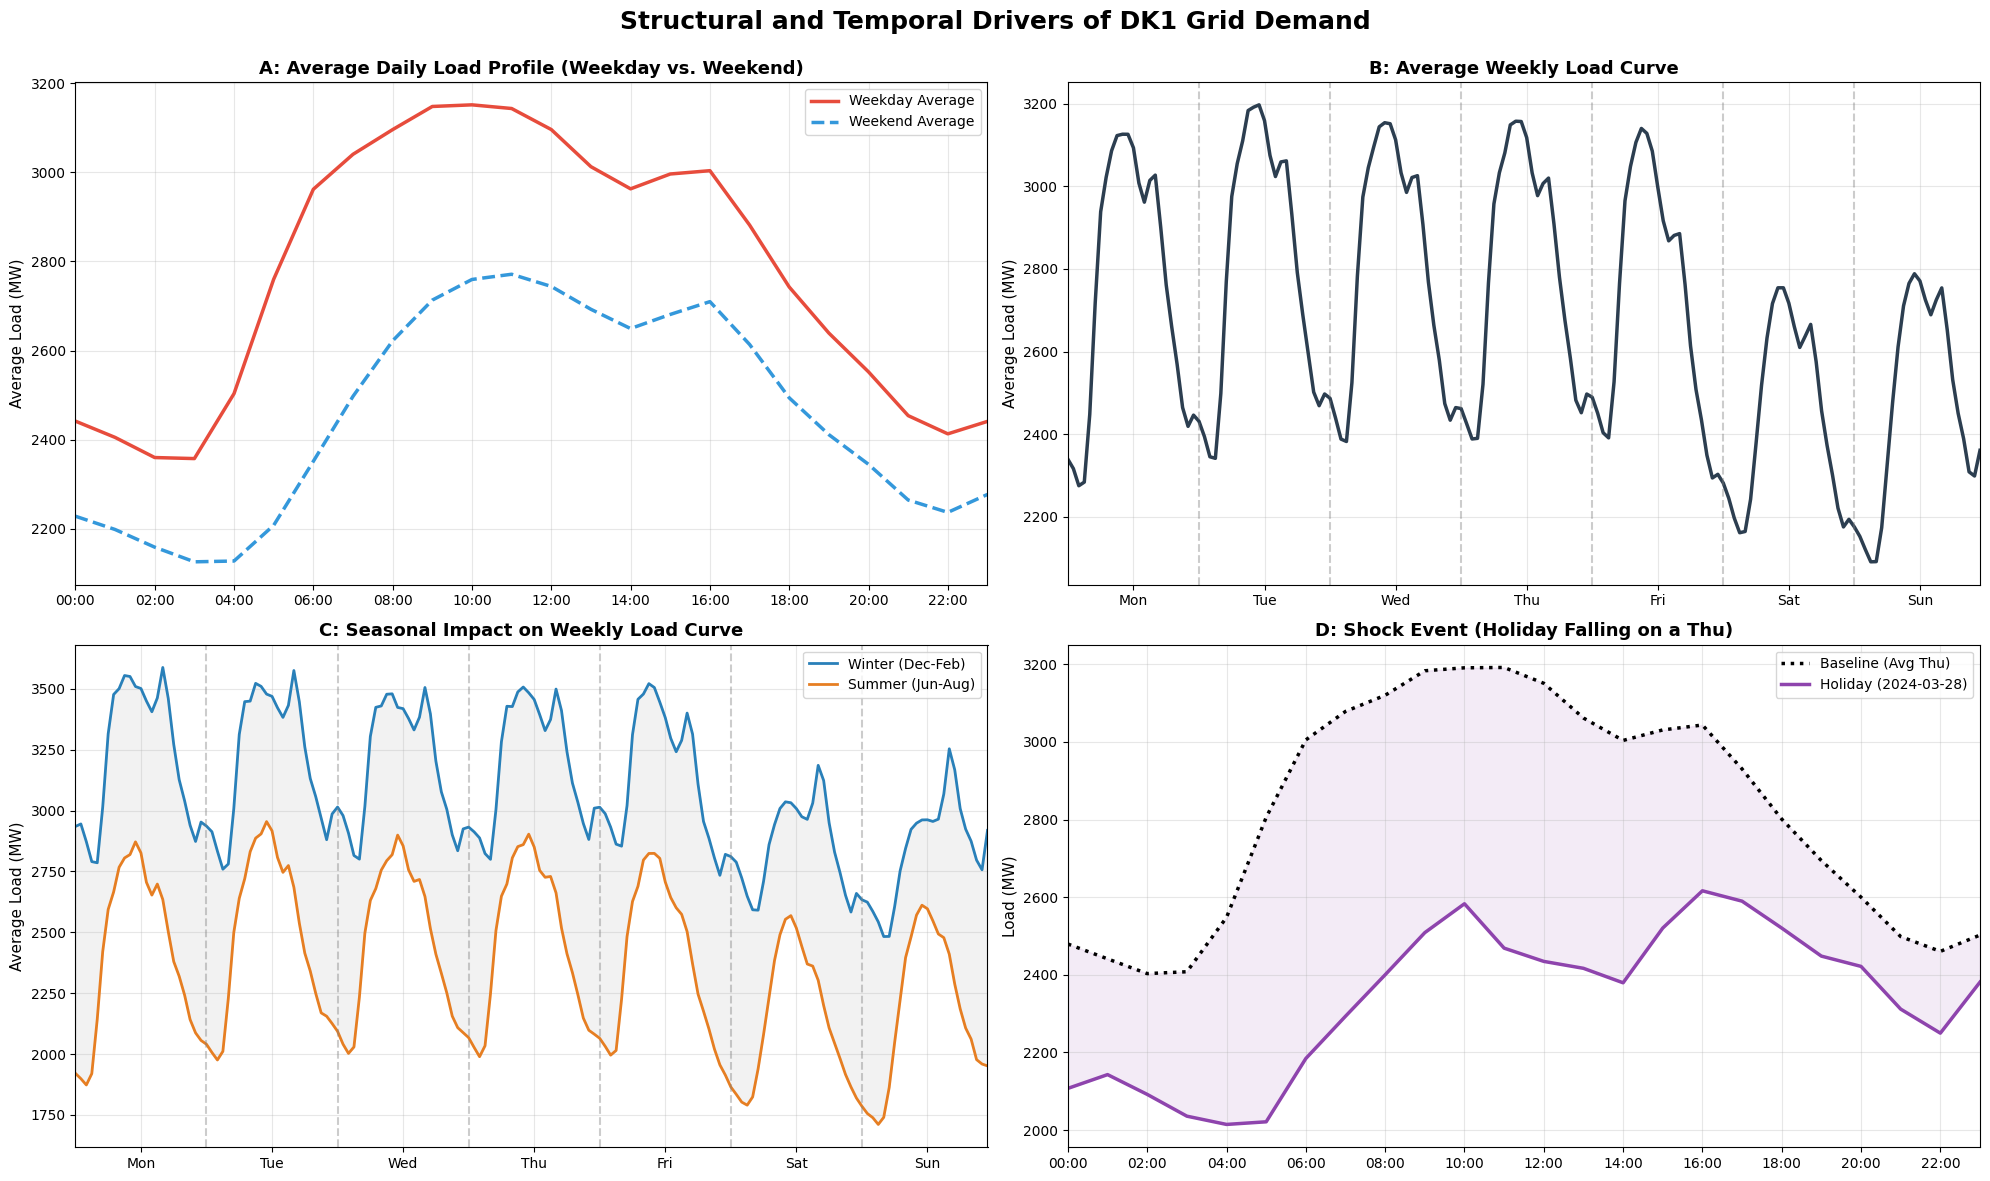

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# DATA PREPARATION
# ==========================================


df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])

# temporal features
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['day_of_week'] = df_raw['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
df_raw['is_weekend'] = df_raw['day_of_week'] >= 5
df_raw['month'] = df_raw['timestamp'].dt.month

# 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Structural and Temporal Drivers of DK1 Grid Demand', fontsize=18, fontweight='bold', y=0.98)

# ==========================================
# PANEL 1: AVERAGE DAILY PROFILE
# ==========================================
ax1 = axes[0, 0]
daily_avg = df_raw.groupby(['is_weekend', 'hour'])['load'].mean().reset_index()
weekday_avg = daily_avg[daily_avg['is_weekend'] == False]
weekend_avg = daily_avg[daily_avg['is_weekend'] == True]

ax1.plot(weekday_avg['hour'], weekday_avg['load'], label='Weekday Average', color='#e74c3c', linewidth=2.5)
ax1.plot(weekend_avg['hour'], weekend_avg['load'], label='Weekend Average', color='#3498db', linewidth=2.5, linestyle='--')

ax1.set_title('A: Average Daily Load Profile (Weekday vs. Weekend)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Load (MW)', fontsize=11)
ax1.set_xticks(np.arange(0, 24, 2))
ax1.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax1.set_xlim(0, 23)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ==========================================
# PANEL 2: AVERAGE WEEKLY CURVE
# ==========================================
ax2 = axes[0, 1]
weekly_avg = df_raw.groupby(['day_of_week', 'hour'])['load'].mean().reset_index()
weekly_avg['hour_of_week'] = weekly_avg['day_of_week'] * 24 + weekly_avg['hour']

ax2.plot(weekly_avg['hour_of_week'], weekly_avg['load'], color='#2c3e50', linewidth=2.5)

ax2.set_title('B: Average Weekly Load Curve', fontsize=13, fontweight='bold')
ax2.set_ylabel('Average Load (MW)', fontsize=11)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax2.set_xticks(np.arange(0, 168, 24) + 12)
ax2.set_xticklabels(days)
for i in range(0, 169, 24):
    ax2.axvline(x=i, color='gray', linestyle='--', alpha=0.4)
ax2.set_xlim(0, 167)
ax2.grid(True, alpha=0.3)

# ==========================================
# PANEL 3: SEASONAL IMPACT
# ==========================================
ax3 = axes[1, 0]
winter_mask = df_raw['month'].isin([12, 1, 2])
summer_mask = df_raw['month'].isin([6, 7, 8])

winter_avg = df_raw[winter_mask].groupby(['day_of_week', 'hour'])['load'].mean().reset_index()
summer_avg = df_raw[summer_mask].groupby(['day_of_week', 'hour'])['load'].mean().reset_index()

winter_avg['hour_of_week'] = winter_avg['day_of_week'] * 24 + winter_avg['hour']
summer_avg['hour_of_week'] = summer_avg['day_of_week'] * 24 + summer_avg['hour']

ax3.plot(winter_avg['hour_of_week'], winter_avg['load'], label='Winter (Dec-Feb)', color='#2980b9', linewidth=2)
ax3.plot(summer_avg['hour_of_week'], summer_avg['load'], label='Summer (Jun-Aug)', color='#e67e22', linewidth=2)
ax3.fill_between(winter_avg['hour_of_week'], summer_avg['load'], winter_avg['load'], color='gray', alpha=0.1)

ax3.set_title('C: Seasonal Impact on Weekly Load Curve', fontsize=13, fontweight='bold')
ax3.set_ylabel('Average Load (MW)', fontsize=11)
ax3.set_xticks(np.arange(0, 168, 24) + 12)
ax3.set_xticklabels(days)
for i in range(0, 169, 24):
    ax3.axvline(x=i, color='gray', linestyle='--', alpha=0.4)
ax3.set_xlim(0, 167)
ax3.legend()
ax3.grid(True, alpha=0.3)

# ==========================================
# PANEL 4: HOLIDAY EFFECT
# ==========================================
ax4 = axes[1, 1]


workday_holidays = df_raw[(df_raw['is_holiday'] == 1) & (df_raw['day_of_week'] < 5)]

if not workday_holidays.empty:
    # Select the first available workday holiday for the case study
    example_date = workday_holidays['timestamp'].dt.date.unique()[1]
    holiday_data = df_raw[df_raw['timestamp'].dt.date == example_date]
    holiday_dow = holiday_data['day_of_week'].iloc[0]
    dow_name = days[holiday_dow]
    
    # Baseline for this specific day
    baseline_data = df_raw[(df_raw['day_of_week'] == holiday_dow) & (df_raw['is_holiday'] == 0)].groupby('hour')['load'].mean().reset_index()
    
    ax4.plot(baseline_data['hour'], baseline_data['load'], label=f'Baseline (Avg {dow_name})', color='black', linewidth=2.5, linestyle=':')
    ax4.plot(holiday_data['hour'], holiday_data['load'], label=f'Holiday ({example_date})', color='#8e44ad', linewidth=2.5)
    
    ax4.fill_between(baseline_data['hour'], holiday_data['load'], baseline_data['load'], color='#8e44ad', alpha=0.1)
    
    ax4.set_title(f'D: Shock Event (Holiday Falling on a {dow_name})', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Load (MW)', fontsize=11)
    ax4.set_xticks(np.arange(0, 24, 2))
    ax4.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
    ax4.set_xlim(0, 23)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No Workday Holidays Found in Dataset', ha='center', va='center')

# Formatting
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

C:\Users\Benedek\AppData\Local\Temp\ipykernel_18132\2429061344.py:19: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  annual_avg['dummy_date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(annual_avg['day_of_year'] - 1, unit='d')


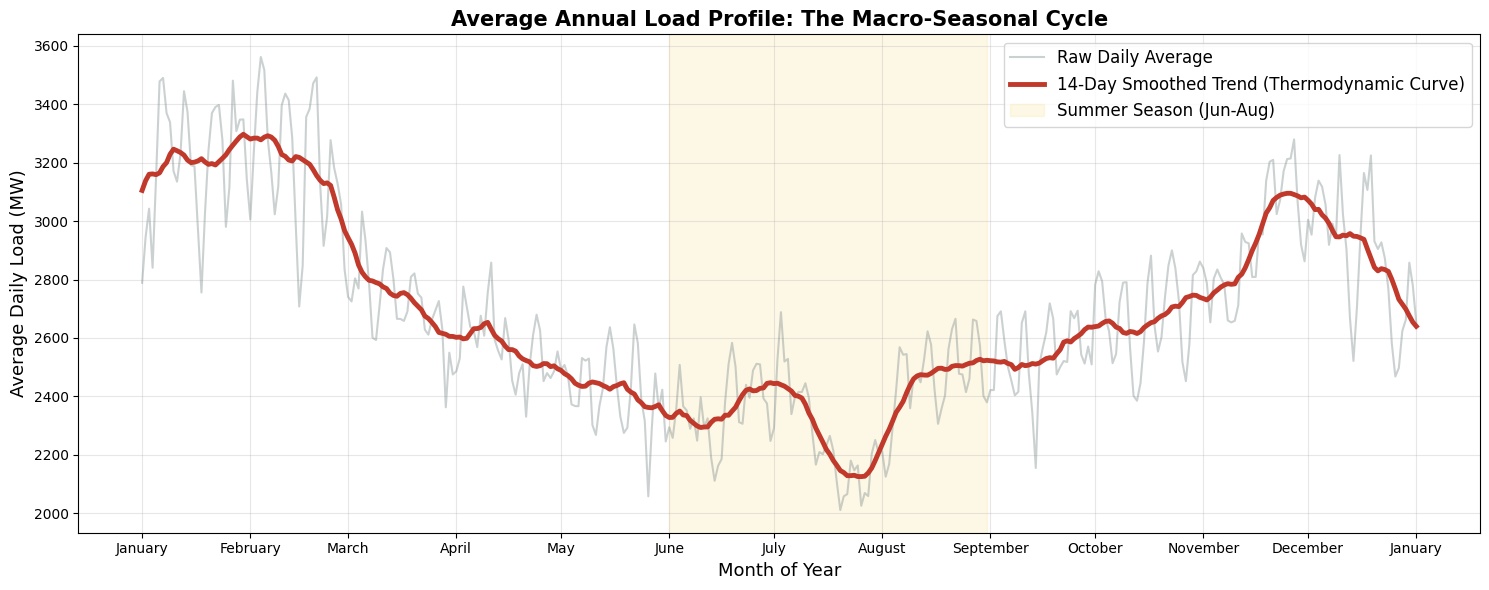

In [ ]:
import matplotlib.dates as mdates

# ==========================================
# TEMPORAL FEATURES
# ==========================================

# doy
df_raw['day_of_year'] = df_raw['timestamp'].dt.dayofyear

# Group by doy and get average daily load
annual_avg = df_raw.groupby('day_of_year')['load'].mean().reset_index()

annual_avg['dummy_date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(annual_avg['day_of_year'] - 1, unit='d')

# 2-week rolling average
annual_avg['smoothed_load'] = annual_avg['load'].rolling(window=14, center=True, min_periods=1).mean()

# ==========================================
# VISUALIZE
# ==========================================
plt.figure(figsize=(15, 6))

# Raw daily averages plot
plt.plot(annual_avg['dummy_date'], annual_avg['load'], 
         label='Raw Daily Average', color='#7f8c8d', linewidth=1.5, alpha=0.4)

# Smoothed seasonal trendline plot
plt.plot(annual_avg['dummy_date'], annual_avg['smoothed_load'], 
         label='14-Day Smoothed Trend (Thermodynamic Curve)', color='#c0392b', linewidth=3.5)

# Formatting
plt.title('Average Annual Load Profile: The Macro-Seasonal Cycle', fontsize=15, fontweight='bold')
plt.ylabel('Average Daily Load (MW)', fontsize=13)
plt.xlabel('Month of Year', fontsize=13)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%B'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())


plt.axvspan(pd.to_datetime('2023-06-01'), pd.to_datetime('2023-08-31'), 
            color='#f1c40f', alpha=0.1, label='Summer Season (Jun-Aug)')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# Holiday  rows for debug
unique_holidays = df_raw[df_raw['is_holiday'] == 1]['timestamp'].dt.date.unique()

# Sort ascending
unique_holidays = sorted(unique_holidays)

print(f"Total unique holidays found: {len(unique_holidays)}")
for holiday in unique_holidays:
    day_name = holiday.strftime('%A')
    print(f"{holiday} ({day_name})")

Total unique holidays found: 32
2024-03-27 (Wednesday)
2024-03-28 (Thursday)
2024-03-29 (Friday)
2024-03-30 (Saturday)
2024-03-31 (Sunday)
2024-04-01 (Monday)
2024-05-08 (Wednesday)
2024-05-09 (Thursday)
2024-05-18 (Saturday)
2024-05-19 (Sunday)
2024-05-20 (Monday)
2024-12-24 (Tuesday)
2024-12-25 (Wednesday)
2024-12-26 (Thursday)
2024-12-31 (Tuesday)
2025-01-01 (Wednesday)
2025-04-16 (Wednesday)
2025-04-17 (Thursday)
2025-04-18 (Friday)
2025-04-19 (Saturday)
2025-04-20 (Sunday)
2025-04-21 (Monday)
2025-05-28 (Wednesday)
2025-05-29 (Thursday)
2025-06-07 (Saturday)
2025-06-08 (Sunday)
2025-06-09 (Monday)
2025-12-24 (Wednesday)
2025-12-25 (Thursday)
2025-12-26 (Friday)
2025-12-31 (Wednesday)
2026-01-01 (Thursday)


Executing STL Decomposition...


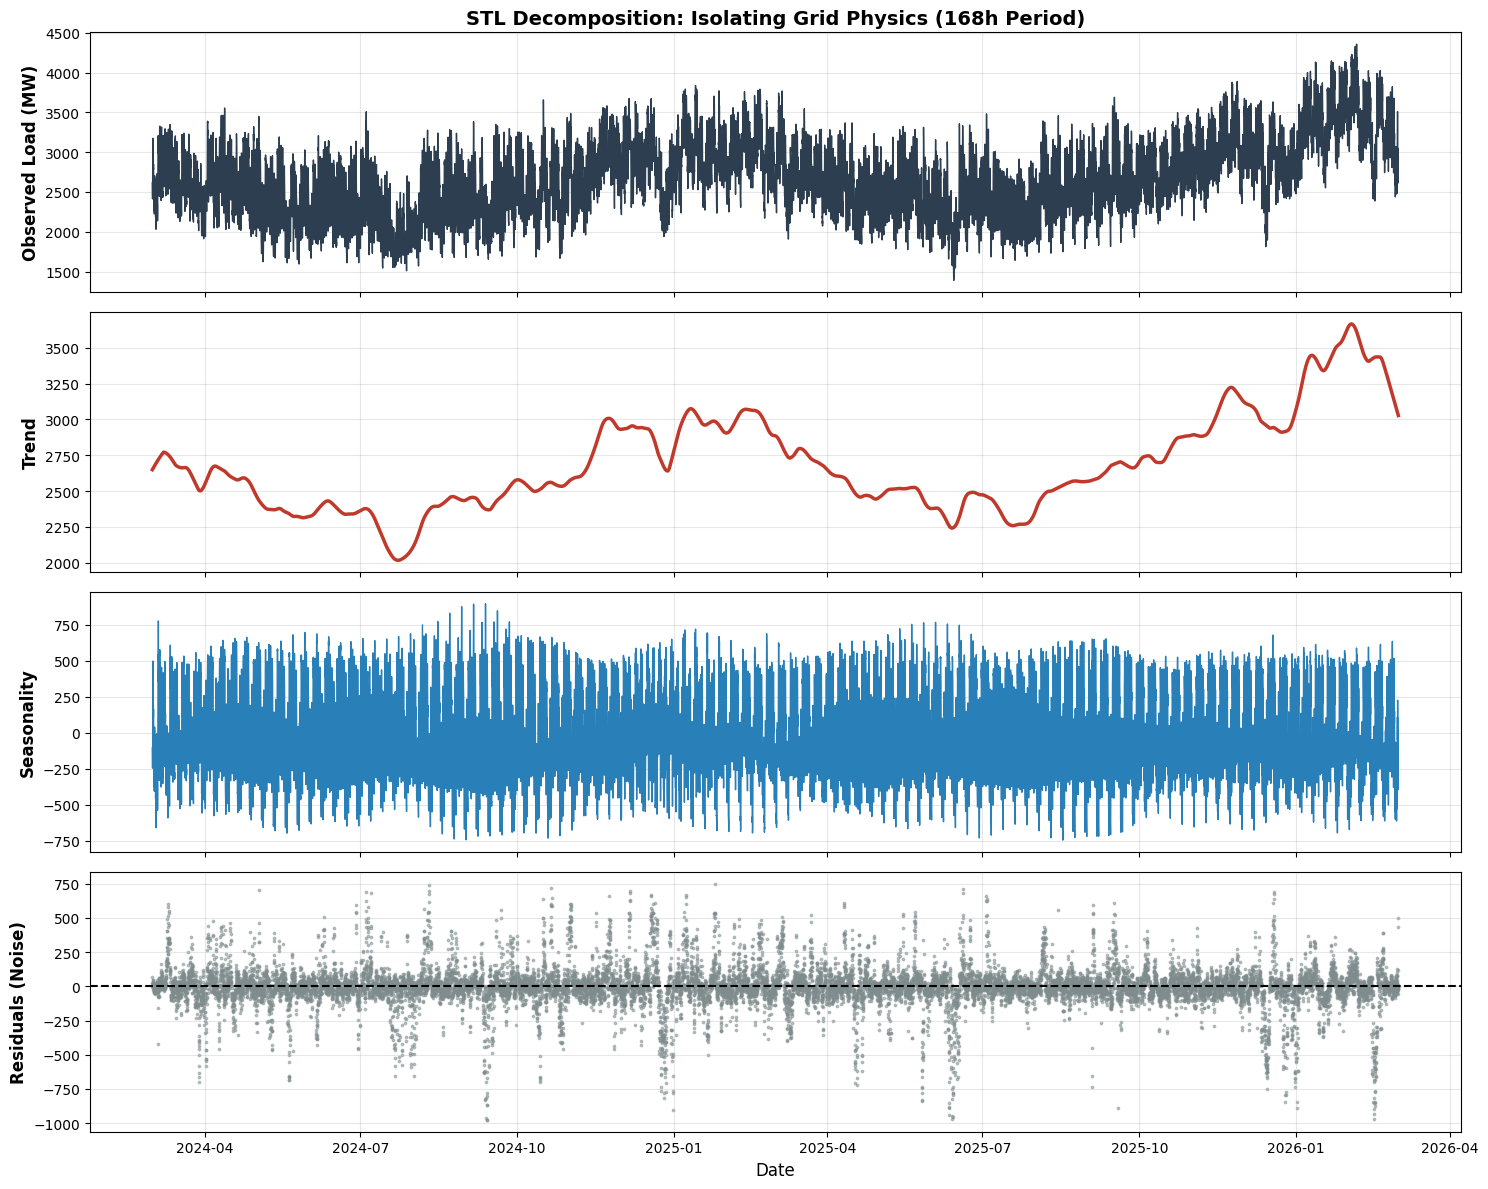

In [ ]:
from statsmodels.tsa.seasonal import STL

# ==========================================
# Preparation
# ==========================================
load_series = df_raw['load'].interpolate(method='linear')

print("Executing STL Decomposition...")
stl = STL(load_series, period=168, robust=True)
result = stl.fit()

# ==========================================
# VISUALIZE COMPONENTS
# ==========================================
# 4-panel architecture
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Panel 1: Observed
ax1.plot(result.observed.index, result.observed.values, color='#2c3e50', linewidth=1)
ax1.set_ylabel('Observed Load (MW)', fontsize=12, fontweight='bold')
ax1.set_title('STL Decomposition: Isolating Grid Physics (168h Period)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Panel 2: Trend
ax2.plot(result.trend.index, result.trend.values, color='#c0392b', linewidth=2.5)
ax2.set_ylabel('Trend', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Panel 3: Seasonality
ax3.plot(result.seasonal.index, result.seasonal.values, color='#2980b9', linewidth=1)
ax3.set_ylabel('Seasonality', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Panel 4: Residuals
ax4.scatter(result.resid.index, result.resid.values, color='#7f8c8d', alpha=0.5, s=3)
ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax4.set_ylabel('Residuals (Noise)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Date', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\s'
<>:62: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Benedek\AppData\Local\Temp\ipykernel_14472\3208330597.py:62: SyntaxWarning: invalid escape sequence '\s'
  ax3.text(0.05, 0.95, f'$\sigma = {std_dev:.2f}$ MW',
C:\Users\Benedek\AppData\Local\Temp\ipykernel_14472\3208330597.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


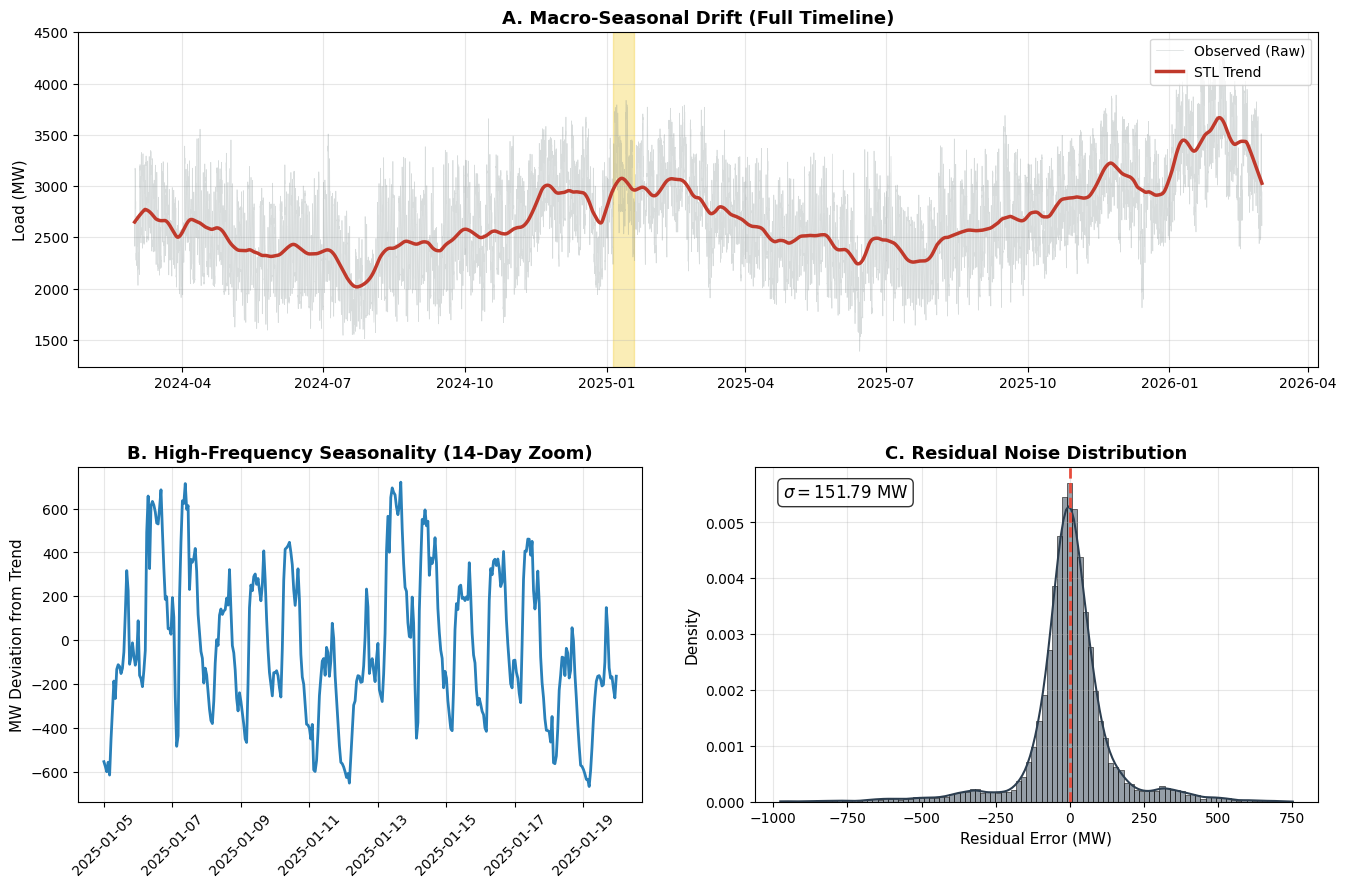

In [ ]:
import seaborn as sns

zoom_start = '2025-01-05'
zoom_end = '2025-01-19'

# Extract components
trend = result.trend
seasonal = result.seasonal
resid = result.resid

# 2x2 grid
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.2)

# ==========================================
# PANEL 1: MACRO TREND
# ==========================================
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(load_series.index, load_series.values, color='#7f8c8d', alpha=0.3, linewidth=0.5, label='Observed (Raw)')
ax1.plot(trend.index, trend.values, color='#c0392b', linewidth=2.5, label='STL Trend')
ax1.set_title('A. Macro-Seasonal Drift (Full Timeline)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Load (MW)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

ax1.axvspan(pd.to_datetime(zoom_start), pd.to_datetime(zoom_end), color='#f1c40f', alpha=0.3)

# ==========================================
# PANEL 2: 14-day Seasonality
# ==========================================
ax2 = fig.add_subplot(gs[1, 0])
seasonal_slice = seasonal.loc[zoom_start:zoom_end]
ax2.plot(seasonal_slice.index, seasonal_slice.values, color='#2980b9', linewidth=2)
ax2.set_title('B. High-Frequency Seasonality (14-Day Zoom)', fontsize=13, fontweight='bold')
ax2.set_ylabel('MW Deviation from Trend', fontsize=11)
ax2.grid(True, alpha=0.3)
# Clean up x-axis dates for the tight zoom
ax2.tick_params(axis='x', rotation=45)

# ==========================================
# PANEL 3: RESIDUAL STATS
# ==========================================
ax3 = fig.add_subplot(gs[1, 1])

sns.histplot(resid.dropna(), bins=100, kde=True, color='#2c3e50', stat='density', ax=ax3)
ax3.set_title('C. Residual Noise Distribution', fontsize=13, fontweight='bold')
ax3.set_xlabel('Residual Error (MW)', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2)
ax3.grid(True, alpha=0.3)

#Stddev in a box
std_dev = np.std(resid.dropna())
ax3.text(0.05, 0.95, f'$\sigma = {std_dev:.2f}$ MW', 
         transform=ax3.transAxes, fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

C:\Users\Benedek\AppData\Local\Temp\ipykernel_6768\915287845.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right')
C:\Users\Benedek\AppData\Local\Temp\ipykernel_6768\915287845.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


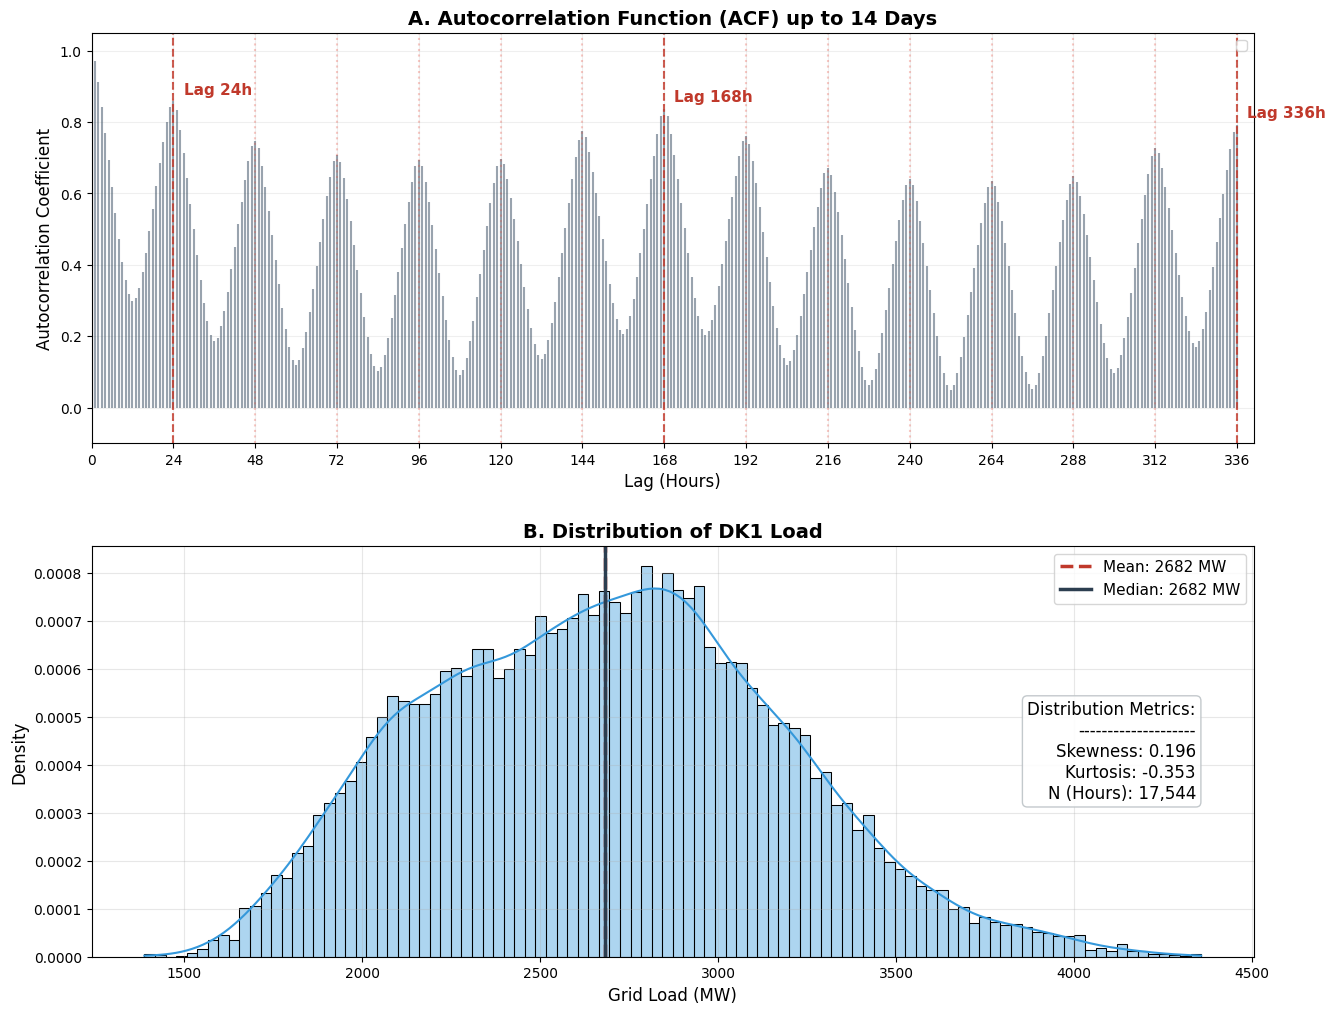

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf

# ==========================================
#PREPARE DATA & METRICS
# ==========================================

load_series = df_raw['load'].interpolate(method='linear')

# Calculate ACF
lags = 336
acf_values = acf(load_series, nlags=lags, fft=True)
conf_int = 1.96 / np.sqrt(len(load_series))


load_mean = load_series.mean()
load_median = load_series.median()
skewness = load_series.skew()
kurtosis = load_series.kurt()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'hspace': 0.25})

# ------------------------------------------
# PANEL A: ACF
# ------------------------------------------
ax1.vlines(x=np.arange(lags + 1), ymin=0, ymax=acf_values, color='#34495e', alpha=0.5, linewidth=1.5)


for lag in range(24, lags + 1, 24):
    ax1.axvline(x=lag, color='#e74c3c', linestyle=':', alpha=0.3)

# Highlight 24, 168, 336
for anchor in [24, 168, 336]:
    ax1.axvline(x=anchor, color='#c0392b', linestyle='--', alpha=0.8)
    ax1.text(anchor + 3, acf_values[anchor] + 0.02, f'Lag {anchor}h', 
             color='#c0392b', fontweight='bold', fontsize=11)

ax1.set_title('A. Autocorrelation Function (ACF) up to 14 Days', fontsize=14, fontweight='bold')
ax1.set_xlabel('Lag (Hours)', fontsize=12)
ax1.set_ylabel('Autocorrelation Coefficient', fontsize=12)
ax1.set_xlim(0, lags + 5)
ax1.set_ylim(min(-0.1, min(acf_values) - 0.1), 1.05)
ax1.set_xticks(np.arange(0, lags + 1, 24))
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)

# ------------------------------------------
# PANEL B: PROBABILITY DENSITY DISTRIBUTION
# ------------------------------------------
sns.histplot(load_series, bins=100, kde=True, color='#3498db', stat='density', alpha=0.4, ax=ax2)

# Means and Medians
ax2.axvline(load_mean, color='#c0392b', linestyle='--', linewidth=2.5, label=f'Mean: {load_mean:.0f} MW')
ax2.axvline(load_median, color='#2c3e50', linestyle='-', linewidth=2.5, label=f'Median: {load_median:.0f} MW')

# Text box for stat metrics
stats_text = (
    f"Distribution Metrics:\n"
    f"--------------------\n"
    f"Skewness: {skewness:.3f}\n"
    f"Kurtosis: {kurtosis:.3f}\n"
    f"N (Hours): {len(load_series):,}"
)
ax2.text(0.95, 0.5, stats_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#bdc3c7'))

ax2.set_title('B. Distribution of DK1 Load', fontsize=14, fontweight='bold')
ax2.set_xlabel('Grid Load (MW)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)

# ==========================================
# 3. EXPORT
# ==========================================
plt.tight_layout()
plt.savefig('load_acf_distribution_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
load_mean

np.float64(2681.615499715524)

In [21]:
load_median

2681.65375